In [1]:
from clustering_variable_label_dictionary import value_labels
from clustering_variable_label_dictionary import display_names
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pickle
import math

In [ ]:
overall_df = pd.read_csv("../../data/master_data/2016_to_2023_full_preprocessed_data_set.csv")
cluster_df = pd.read_csv("../../data/master_data/2016_to_2023_clustering_input_data.csv")

In [ ]:
cluster_cols = ["Age9",
                "Gend3",
                "Eth7",
                "Disab2_POP",
                "Educ6",
                "NSSEC5",
                "IMD10",
                "WorkStat8",
                "Child4",
                "HHLiv9",
                "Motiva_POP",
                "motivd_POP"]

original_codes = {col: np.sort(cluster_df[col].dropna().unique()) for col in cluster_cols}

n_categories = [cluster_df[col].nunique() for col in cluster_cols]

In [ ]:
def load_model(n_classes):

    with open(f"stepmix_{n_classes}_class_model.pkl", "rb") as f:
        model = pickle.load(f)

    measurement = model.get_parameters()["measurement"]

    pis = measurement["pis"]
    block_size = measurement["max_n_outcomes"]

    return model, pis, block_size

In [ ]:
def create_class_summary(model, pis, block_size, cluster_df, n_categories):

    n_classes = pis.shape[0]

    print(f"\n{n_classes} classes")

    X = cluster_df[cluster_cols]

    posterior = model.predict_proba(X)
    class_sizes = posterior.mean(axis=0)    

    summary_rows = []

    for cls in range(n_classes):

        row = {"Class": cls, "Size": f"{class_sizes[cls]:.1%}"}

        for i, (var, ncat) in enumerate(zip(cluster_cols, n_categories)):

            start = i * block_size

            probs = pis[cls, start:start + block_size][:ncat]

            top = np.argsort(probs)[::-1][:3]

            entries = []

            label_dict = value_labels[var]

            for idx in top:

                code = original_codes[var][idx]

                label = label_dict[code]

                entries.append(f"{label} ({probs[idx]:.0%})")

            row[var] = ", ".join(entries)

        summary_rows.append(row)

    class_summary = pd.DataFrame(summary_rows)

    # print(class_summary)

    class_summary.to_csv(f"stepmix_{n_classes}_class_summary.csv", index=False)

    return class_summary, class_sizes

In [6]:
def assign_classes(model, cluster_df):

    X = cluster_df[cluster_cols]

    cluster_df = cluster_df.copy()
    cluster_df["Class"] = model.predict(X)

    return cluster_df

In [ ]:
def create_master_dataset(overall_df, cluster_df):

    assert cluster_df.set_index(["year", "serial"]).index.is_unique

    merge_cols = [col for col in overall_df.columns if col not in cluster_cols + ["year", "serial"]]

    master_df = cluster_df.merge(overall_df[["year", "serial"] + merge_cols], on=["year", "serial"], how="left", validate="one_to_one")

    master_df = master_df.rename(columns={"Class": "LCA_Class"})

    selected_columns = ["serial",
        "year",
        "wt_final",
        "month",
        "LCA_Class",
        "LA_2023",
        "Age9",
        "Gend3",
        "Eth7",
        "Disab2_POP",
        "Educ6",
        "NSSEC5",
        "IMD10",
        "WorkStat8",
        "Child4",
        "HHLiv9",
        "Motiva_POP",
        "motivd_POP",
        "nadult",
        "nchild",
        "health", 
        "comm1",
        "anxious",
        "happy",
        "lifesat",
        "lone",
        "DVBMI",
        "FruitVegPor",
        "READYAB1_POP",
        "CULFRQ_1_9_POP",
        "VolAny",
        "VolCnt",
        "VolDur",
        "VolFrqB_Pop",
        "volint1",
        "volint2",
        "volint3",
        "volint4",
        "volint5",
        "volint6",
        "volint7",
        "MEMS7_ALL",
        "MEMS7_SPORTCOUNT_A01",
        "MEMS7_IN_SPORTCOUNT_A01",
        "MEMS7_OUT_SPORTCOUNT_A01",
        "MEMS7_FITNESS_B06",
        "MEMS7_WALKALL_C01",
        "MEMS7_CYCALL_C02",
        "MEMS7_ACTTRAV_C03",
        "MEMS7_DANCEALL_C04",
        "MEMS7_TEAMSPORT_C05",
        "MEMS7_RACKETSPORT_C06",
        "MEMS7_ADVWATERSPORT_C07",
        "MEMS7_LEISURE_C08",
        "MEMS7_COMBATTARGET_C09",
        "MEMS7_WINTER_C10",
        "MEMS7_RUNATHMULTI_C11",
        "ACT7GR_ALL",
        "ACT7GR_SPORTCOUNT_A01",
        "Number_Activities",
        "CLUB_SPORTCOUNT_A01",
        "Number_Club"]

    master_df = master_df[selected_columns]

    master_df["LCA_Class"] = (master_df["LCA_Class"].astype("Int64"))

    print(f"Rows in overall_df : {len(overall_df):,}")
    print(f"Rows in master_df  : {len(master_df):,}")
    print(f"Assigned to LCA    : {master_df['LCA_Class'].notna().sum():,}")
    print(f"Missing LCA class  : {master_df['LCA_Class'].isna().sum():,}")

    master_df.to_csv("../../data/master_data/2016_to_2023_clustering_output_data.csv", index=False)

    return master_df

In [ ]:
def create_forecasting_summary(master_df):

    forecasting_summary = (master_df.dropna(subset=["LCA_Class"]).groupby(["LCA_Class", "year"]).agg(N=("serial", "size"),
            Sum_wt_final=("wt_final", "sum"),
            Mean_wt_final=("wt_final", "mean"),
            Mean_MEMS7_ALL=("MEMS7_ALL", "mean"),
            Median_MEMS7_ALL=("MEMS7_ALL", "median"),
            SD_MEMS7_ALL=("MEMS7_ALL", "std"),
            Mean_MEMS7_SPORTCOUNT_A01=("MEMS7_SPORTCOUNT_A01", "mean"),
            Median_MEMS7_SPORTCOUNT_A01=("MEMS7_SPORTCOUNT_A01", "median"),
            Mean_MEMS7_IN_SPORTCOUNT_A01=("MEMS7_IN_SPORTCOUNT_A01", "mean"),
            Median_MEMS7_IN_SPORTCOUNT_A01=("MEMS7_IN_SPORTCOUNT_A01", "median"),
            Mean_MEMS7_OUT_SPORTCOUNT_A01=("MEMS7_OUT_SPORTCOUNT_A01", "mean"),
            Median_MEMS7_OUT_SPORTCOUNT_A01=("MEMS7_OUT_SPORTCOUNT_A01", "median"),
            Mean_MEMS7_FITNESS_B06=("MEMS7_FITNESS_B06", "mean"),
            Median_MEMS7_FITNESS_B06=("MEMS7_FITNESS_B06", "median"),
            Mean_MEMS7_WALKALL_C01=("MEMS7_WALKALL_C01", "mean"),
            Median_MEMS7_WALKALL_C01=("MEMS7_WALKALL_C01", "median"),
            Mean_MEMS7_CYCALL_C02=("MEMS7_CYCALL_C02", "mean"),
            Median_MEMS7_CYCALL_C02=("MEMS7_CYCALL_C02", "median"),
            Mean_MEMS7_ACTTRAV_C03=("MEMS7_ACTTRAV_C03", "mean"),
            Median_MEMS7_ACTTRAV_C03=("MEMS7_ACTTRAV_C03", "median"),
            Mean_MEMS7_DANCEALL_C04=("MEMS7_DANCEALL_C04", "mean"),
            Median_MEMS7_DANCEALL_C04=("MEMS7_DANCEALL_C04", "median"),
            Mean_MEMS7_TEAMSPORT_C05=("MEMS7_TEAMSPORT_C05", "mean"),
            Median_MEMS7_TEAMSPORT_C05=("MEMS7_TEAMSPORT_C05", "median"),
            Mean_MEMS7_RACKETSPORT_C06=("MEMS7_RACKETSPORT_C06", "mean"),
            Median_MEMS7_RACKETSPORT_C06=("MEMS7_RACKETSPORT_C06", "median"),
            Mean_MEMS7_ADVWATERSPORT_C07=("MEMS7_ADVWATERSPORT_C07", "mean"),
            Median_MEMS7_ADVWATERSPORT_C07=("MEMS7_ADVWATERSPORT_C07", "median"),
            Mean_MEMS7_LEISURE_C08=("MEMS7_LEISURE_C08", "mean"),
            Median_MEMS7_LEISURE_C08=("MEMS7_LEISURE_C08", "median"),
            Mean_MEMS7_COMBATTARGET_C09=("MEMS7_COMBATTARGET_C09", "mean"),
            Median_MEMS7_COMBATTARGET_C09=("MEMS7_COMBATTARGET_C09", "median"),
            Mean_MEMS7_WINTER_C10=("MEMS7_WINTER_C10", "mean"),
            Median_MEMS7_WINTER_C10=("MEMS7_WINTER_C10", "median"),
            Mean_MEMS7_RUNATHMULTI_C11=("MEMS7_RUNATHMULTI_C11", "mean"),
            Median_MEMS7_RUNATHMULTI_C11=("MEMS7_RUNATHMULTI_C11", "median"),
            Median_ACT7GR_ALL=("ACT7GR_ALL", "median"),
            Median_ACT7GR_SPORTCOUNT_A01=("ACT7GR_SPORTCOUNT_A01", "median"),
            Mean_Number_Activities=("Number_Activities", "mean"),
            Median_Number_Activities=("Number_Activities", "median"),
            Mean_CLUB_SPORTCOUNT_A01=("CLUB_SPORTCOUNT_A01", "mean"),
            Mean_Number_Club=("Number_Club", "mean"),
            Median_Number_Club=("Number_Club", "median"),
            Mean_VolAny=("VolAny", "mean"),
            Mean_VolCnt=("VolCnt", "mean"),
            Median_VolCnt=("VolCnt", "median"),
            Mean_VolDur=("VolDur", "mean"),
            Median_VolDur=("VolDur", "median"),
            Mean_VolFrqB_Pop=("VolFrqB_Pop", "mean"),
            Median_VolFrqB_Pop=("VolFrqB_Pop", "median"),
            Mean_volint1=("volint1", "mean"),
            Mean_volint2=("volint2", "mean"),
            Mean_volint3=("volint3", "mean"),
            Mean_volint4=("volint4", "mean"),
            Mean_volint5=("volint5", "mean"),
            Mean_volint6=("volint6", "mean"),
            Mean_volint7=("volint7", "mean"),
            Mean_DVBMI=("DVBMI", "mean"),
            Median_DVBMI=("DVBMI", "median"),
            Mean_FruitVegPor=("FruitVegPor", "mean"),
            Median_FruitVegPor=("FruitVegPor", "median"))
            .reset_index())
    
    forecasting_summary.to_csv("../../data/master_data/latent_class_forecasting_data.csv", index=False)

    return forecasting_summary

In [16]:
def calculate_dominance(class_probabilities, class_sizes, n_categories):

    n_classes = class_probabilities.shape[0]

    dominance_rows = []

    for cls in range(n_classes):

        row = {"Class": cls, "Size": round(class_sizes[cls], 3)}

        for i, (var, ncat) in enumerate(zip(cluster_cols, n_categories)):

            probs = class_probabilities[cls, i, :ncat]

            row[var] = probs.max()

        dominance_rows.append(row)

    dominance = pd.DataFrame(dominance_rows)

    # print(dominance.round(2))

    return dominance

In [ ]:
def plot_heatmap(class_probabilities, cluster_df, n_categories, original_codes):

    n_classes = class_probabilities.shape[0]

    n_plots = len(cluster_cols)
    ncols = 4
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 6 * nrows))

    axes = np.array(axes).flatten()

    for i, (ax, var) in enumerate(zip(axes, cluster_cols)):

        ncat = n_categories[i]

        population = (cluster_df[var].value_counts(normalize=True).sort_index().values)

        heat = class_probabilities[:, i, :ncat] - population

        codes = original_codes[var]

        labels = [value_labels[var][code] for code in codes]

        if var == "IMD10":
            labels = [f"D{i+1}" for i in range(len(labels))]

        sns.heatmap(heat,
                    ax=ax,
                    cmap="RdBu_r",
                    center=0,
                    vmin=-0.5,
                    vmax=0.5,
                    linewidths=0.3,
                    linecolor="white",
                    xticklabels=labels,
                    yticklabels=False)

        ax.set_title(display_names[var], fontsize=11, fontweight="bold")

        if i % ncols == 0:
            ax.set_yticks(np.arange(n_classes) + 0.5)
            ax.set_yticklabels(range(1, n_classes + 1), fontsize=8)
            ax.set_ylabel("Class")
        else:
            ax.set_yticks([])

        ax.tick_params(axis="x", labelsize=9, rotation=30)

        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    for ax in axes[n_plots:]:
        ax.axis("off")

    plt.suptitle("Latent class profiles relative to the London population", fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    plt.show()

In [ ]:
class_names = {
    0:  "Mid-life working fathers",
    1:  "Young highly educated professional women",
    2:  "Older unemployed disadvantaged adults",
    3:  "Young adults living with parents",
    4:  "Affluent older working women",
    5:  "Oldest retired adults 1",
    6:  "Mid-life professional women",
    7:  "Highly educated professional fathers",
    8:  "Young highly educated professionals",
    9:  "Disabled mid-life adults",
    10: "Affluent older professionals",
    11: "Older middle socioeconomic workers",
    12: "Lone mothers in lower socioeconomic households",
    13: "Oldest retired adults 2",
    14: "Established professional adults",
    15: "Older transitioning retirees",
    16: "Young students living with parents",
    17: "University students in shared housing",
    18: "Young Asian professionals",
    19: "Lower socioeconomic family mothers",
    20: "Highly educated young professionals",
    21: "Professional mothers",
    22: "Working family mothers",
    23: "Retired older adults",
    24: "Affluent retired older adults",
}

In [ ]:
def plot_mems_trends(forecasting_summary):

        n_classes = forecasting_summary["LCA_Class"].nunique()

        ncols = 4
        nrows = math.ceil(n_classes / ncols)

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharex=True, sharey=True)

        axes = np.array(axes).flatten()
        
        years = sorted(forecasting_summary["year"].unique())

        ymax = forecasting_summary["Median_MEMS7_ALL"].max()

        for cls in range(n_classes):

                ax = axes[cls]

                tmp = forecasting_summary[forecasting_summary["LCA_Class"] == cls]

                tmp = tmp.sort_values("year")
                
                ax.plot(tmp["year"], tmp["Median_MEMS7_ALL"], marker="o", linewidth=2)

                ax.set_xticks(years)

                ax.set_title(class_names.get(cls, f"Class {cls + 1}"), fontsize=9, fontweight="bold")

                ax.grid(alpha=0.3)

                padding = 0.05 * ymax

                ax.set_ylim(0, ymax + padding)

        for ax in axes[n_classes:]:
                        ax.axis("off")

        for ax in axes[-ncols:]:
                ax.set_xlabel("Year", fontsize=9)
                ax.tick_params(axis="x", rotation=30)

        for ax in axes[::ncols]:
                ax.set_ylabel("Median MEMS7", fontsize=9)

        fig.suptitle("Median MEMS7 over time by latent class", fontsize=16, fontweight="bold")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


25 classes
Rows in overall_df : 117,679
Rows in master_df  : 117,679
Assigned to LCA    : 85,013
Missing LCA class  : 32,666


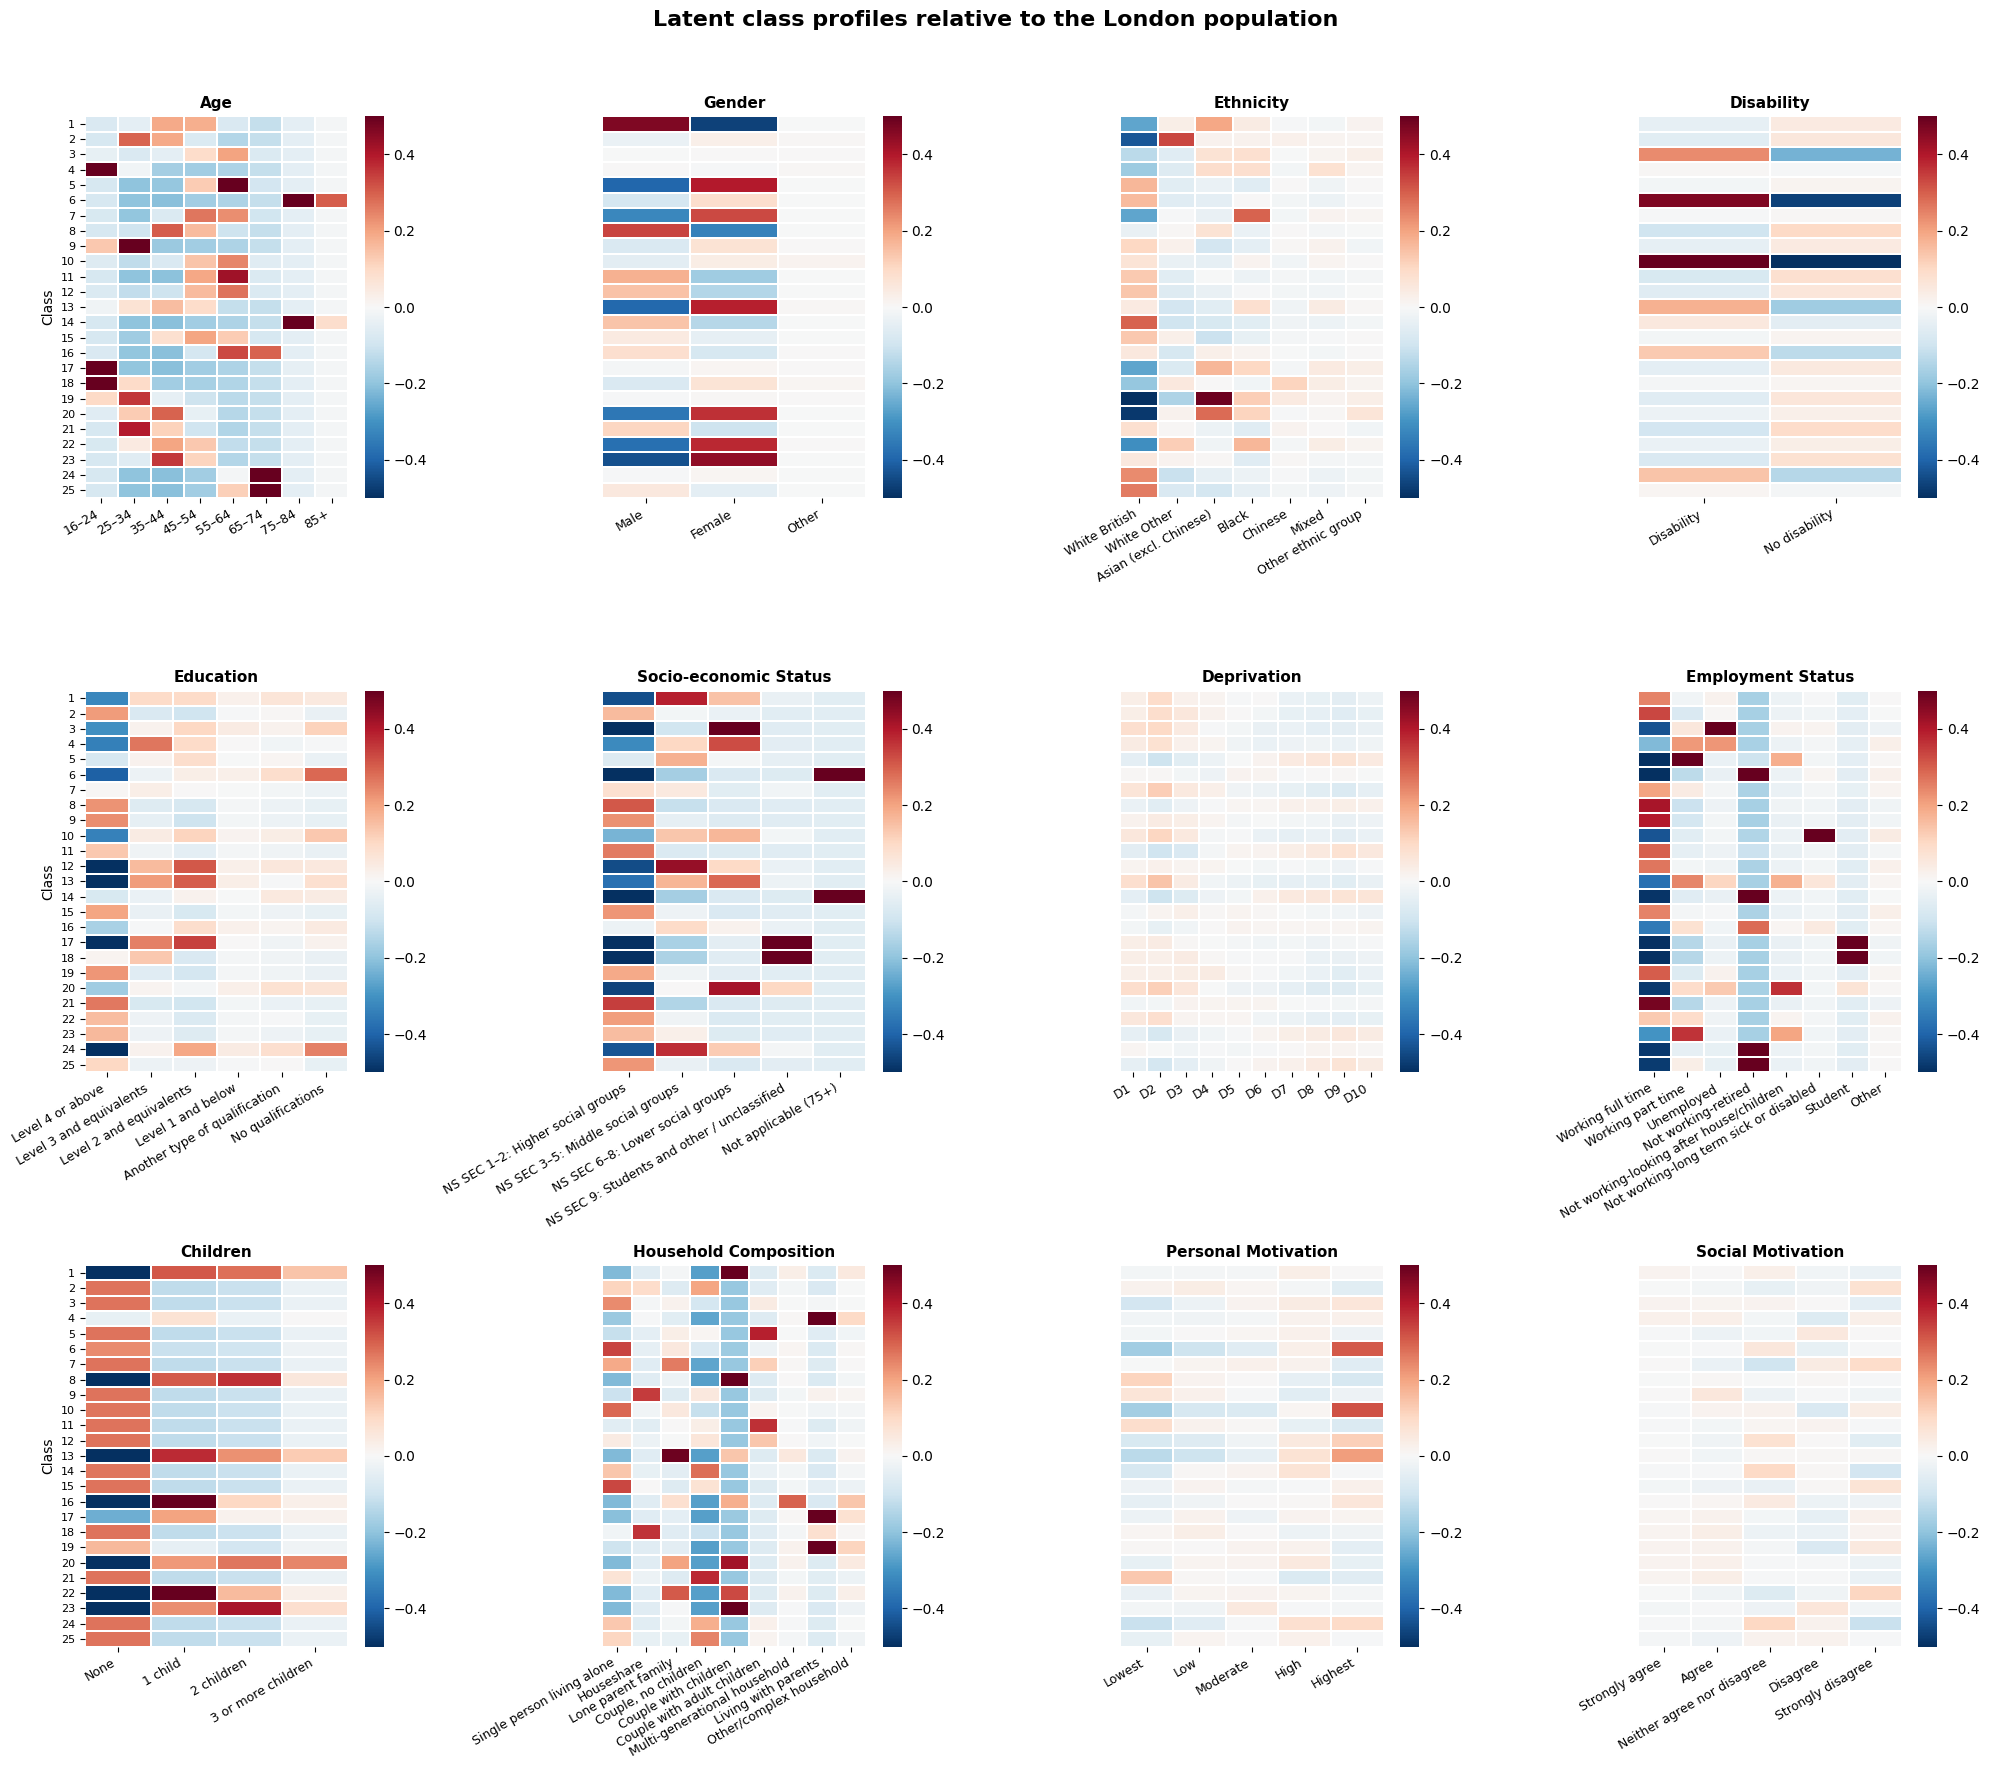

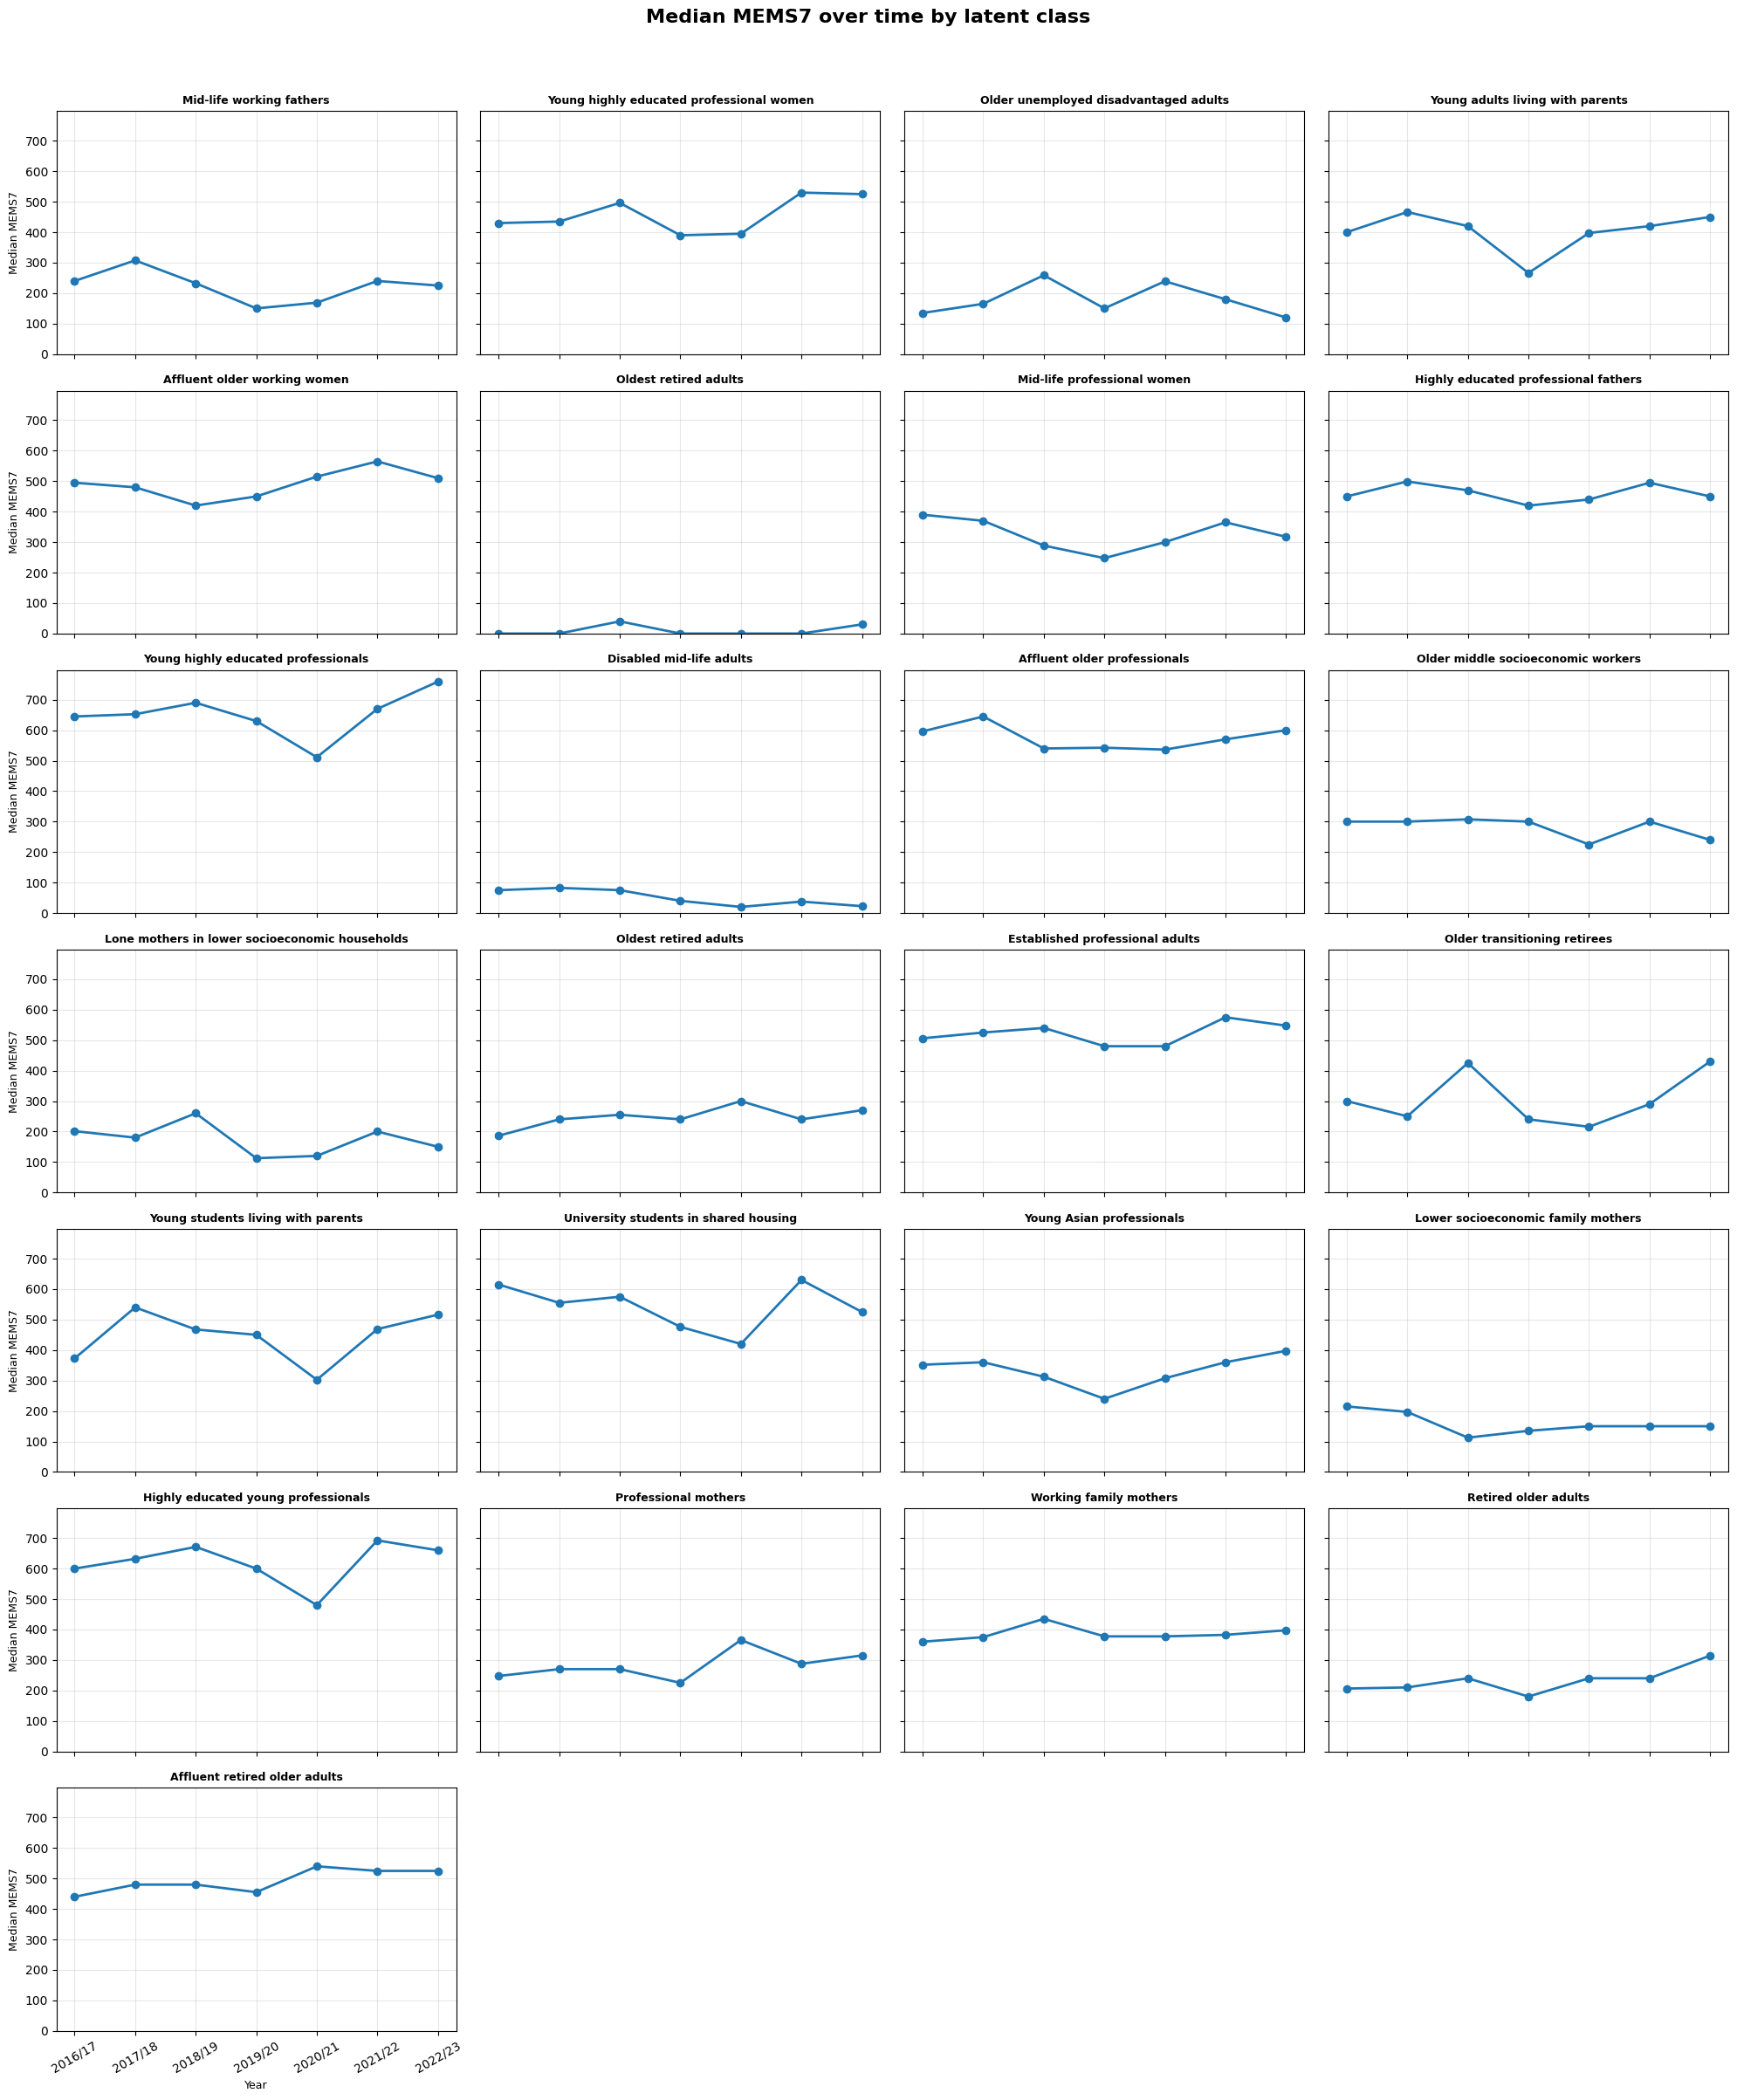

In [20]:
for n_classes in [25]:

    model, pis, block_size = load_model(n_classes)

    class_summary, class_sizes = create_class_summary(model, pis, block_size, cluster_df, n_categories)

    cluster_df_model = assign_classes(model, cluster_df)

    master_df = create_master_dataset(overall_df, cluster_df_model)

    forecasting_summary = create_forecasting_summary(master_df)

    class_probabilities = pis.reshape(pis.shape[0], len(cluster_cols), block_size)

    dominance = calculate_dominance(class_probabilities, class_sizes, n_categories)

    plot_heatmap(class_probabilities, cluster_df_model, n_categories, original_codes)

    plot_mems_trends(forecasting_summary)